In [1]:
import pandas as pd

df = pd.read_csv("laps_dataset_v3.csv")
df.head()



,Driver,Team,LapNumber,LapTime,Compound,Stint,TrackStatus,IsAccurate,LapTimeSeconds,Year,...,Rainfall,TyreAgeLaps,SessionProgress,LapTimeFormatted,FuelKg,EstimatedCarWeightKg,CompoundEffect,Intensity,TyreAgeEffect,EstimatedTyreTempC
0,ALB,Williams,2.0,0 days 00:01:20.820000,SOFT,1.0,1,True,80.820,2024,...,0.0,0,Early,1:20.820,10.0,808.0,8,-0.354424,0.0,54.603836
1,ALB,Williams,5.0,0 days 00:01:20.542000,SOFT,2.0,1,True,80.542,2024,...,0.0,0,Early,1:20.542,10.0,808.0,8,-0.074111,0.0,56.285711
2,ALB,Williams,8.0,0 days 00:01:20.460000,SOFT,3.0,1,True,80.460,2024,...,0.0,0,Mid,1:20.460,10.0,808.0,8,0.008571,0.0,56.781804
3,ALB,Williams,11.0,0 days 00:01:20.314000,SOFT,4.0,1,True,80.314,2024,...,0.0,0,Mid,1:20.314,10.0,808.0,8,0.155785,0.0,57.665091
4,ALB,Williams,14.0,0 days 00:01:20.870000,SOFT,5.0,1,True,80.870,2024,...,0.0,0,Late,1:20.870,10.0,808.0,8,-0.404840,0.0,54.301340


In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3474 entries, 0 to 3473
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Driver                3474 non-null   object 
 1   Team                  3474 non-null   object 
 2   LapNumber             3474 non-null   float64
 3   LapTime               3474 non-null   object 
 4   Compound              3474 non-null   object 
 5   Stint                 3474 non-null   float64
 6   TrackStatus           3474 non-null   int64  
 7   IsAccurate            3474 non-null   bool   
 8   LapTimeSeconds        3474 non-null   float64
 9   Year                  3474 non-null   int64  
 10  Track                 3474 non-null   object 
 11  Session               3474 non-null   object 
 12  AirTempC              3474 non-null   float64
 13  TrackTempC            3474 non-null   float64
 14  Rainfall              3474 non-null   float64
 15  TyreAgeLaps          

In [3]:
print("Rows:", len(df))
print("Columns:", df.columns.tolist())
print("\nMissing values per column:\n", df.isna().sum().sort_values(ascending=False).head(15))


Rows: 3474
Columns: ['Driver', 'Team', 'LapNumber', 'LapTime', 'Compound', 'Stint', 'TrackStatus', 'IsAccurate', 'LapTimeSeconds', 'Year', 'Track', 'Session', 'AirTempC', 'TrackTempC', 'Rainfall', 'TyreAgeLaps', 'SessionProgress', 'LapTimeFormatted', 'FuelKg', 'EstimatedCarWeightKg', 'CompoundEffect', 'Intensity', 'TyreAgeEffect', 'EstimatedTyreTempC']

Missing values per column:
 Driver                  0
Team                    0
TyreAgeEffect           0
Intensity               0
CompoundEffect          0
EstimatedCarWeightKg    0
FuelKg                  0
LapTimeFormatted        0
SessionProgress         0
TyreAgeLaps             0
Rainfall                0
TrackTempC              0
AirTempC                0
Session                 0
Track                   0
dtype: int64


In [4]:
features = [
    "LapNumber",
    "FuelKg",
    "EstimatedCarWeightKg",
    "AirTempC",
    "TrackTempC",
    "Rainfall",
    "TyreAgeLaps",
    "CompoundEffect",
    "Intensity",
    "TyreAgeEffect",
    "EstimatedTyreTempC"
]

X = df[features]
y = df["LapTimeSeconds"]

X.head(), y.head()


(   LapNumber  FuelKg  EstimatedCarWeightKg  AirTempC  TrackTempC  Rainfall  \
 0        2.0    10.0                 808.0  33.44557    48.73038       0.0   
 1        5.0    10.0                 808.0  33.44557    48.73038       0.0   
 2        8.0    10.0                 808.0  33.44557    48.73038       0.0   
 3       11.0    10.0                 808.0  33.44557    48.73038       0.0   
 4       14.0    10.0                 808.0  33.44557    48.73038       0.0   
 
    TyreAgeLaps  CompoundEffect  Intensity  TyreAgeEffect  EstimatedTyreTempC  
 0            0               8  -0.354424            0.0           54.603836  
 1            0               8  -0.074111            0.0           56.285711  
 2            0               8   0.008571            0.0           56.781804  
 3            0               8   0.155785            0.0           57.665091  
 4            0               8  -0.404840            0.0           54.301340  ,
 0    80.820
 1    80.542
 2    80.460
 3  

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [6]:
from sklearn.model_selection import train_test_split


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)


In [8]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (2779, 11)
X_test shape: (695, 11)
y_train shape: (2779,)
y_test shape: (695,)


In [9]:
from sklearn.linear_model import LinearRegression


In [10]:
model = LinearRegression()


In [11]:
model.fit(X_train, y_train)


LinearRegression()

In [12]:
y_pred = model.predict(X_test)


In [13]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (seconds):", mae)
print("R² Score:", r2)


Mean Absolute Error (seconds): 2.6637925812918066
R² Score: 0.778306071297991


In [14]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.coef_
}).sort_values(by="Importance", ascending=False)

coefficients


,Feature,Importance
10,EstimatedTyreTempC,1.094756e+14
2,EstimatedCarWeightKg,1.868218e+13
5,Rainfall,1.018074e+13
3,AirTempC,4.478736e+00
0,LapNumber,1.145455e-01
6,TyreAgeLaps,8.622448e-02
1,FuelKg,-1.868218e+13
7,CompoundEffect,-1.943257e+13
8,Intensity,-3.037057e+13
9,TyreAgeEffect,-3.381884e+13


In [15]:
# Step 1: Define degradation physics constants
BASE_DEGRADATION = 0.015
TEMP_FACTOR = 0.002
INTENSITY_FACTOR = 0.01
COMPOUND_FACTOR = 0.004
RAIN_REDUCTION = 0.5


In [16]:
# Step 2: Calculate degradation rate per lap

df["TyreDegradationRate"] = (
    BASE_DEGRADATION
    + TEMP_FACTOR * (df["EstimatedTyreTempC"] - 70)
    + INTENSITY_FACTOR * df["Intensity"]
    + COMPOUND_FACTOR * df["CompoundEffect"]
)

# Reduce degradation if raining
df["TyreDegradationRate"] *= (1 - RAIN_REDUCTION * df["Rainfall"])

# Ensure degradation is never negative
df["TyreDegradationRate"] = df["TyreDegradationRate"].clip(lower=0.002)


In [17]:
# Step 3: Compute tyre health (100% to 0%)

df["TyreHealth"] = 1 - df.groupby(["Driver", "Stint"])["TyreDegradationRate"].cumsum()
df["TyreHealth"] = df["TyreHealth"].clip(0, 1)


In [18]:
# Step 4: Estimate remaining tyre life in laps

df["RemainingTyreLifeLaps"] = df["TyreHealth"] / df["TyreDegradationRate"]


In [19]:
df[[
    "Compound", 
    "TyreAgeLaps", 
    "EstimatedTyreTempC", 
    "Intensity",
    "TyreDegradationRate",
    "TyreHealth",
    "RemainingTyreLifeLaps"
]].head(10)


,Compound,TyreAgeLaps,EstimatedTyreTempC,Intensity,TyreDegradationRate,TyreHealth,RemainingTyreLifeLaps
0,SOFT,0,54.603836,-0.354424,0.012663,0.987337,77.967537
1,SOFT,0,56.285711,-0.074111,0.018830,0.981170,52.105875
2,SOFT,0,56.781804,0.008571,0.020649,0.979351,47.427756
3,SOFT,0,57.665091,0.155785,0.023888,0.976112,40.861962
4,SOFT,0,54.301340,-0.404840,0.011554,0.988446,85.548007
5,SOFT,0,57.755840,0.170910,0.024221,0.975779,40.286863
6,SOFT,0,55.831968,-0.149735,0.017167,0.982833,57.252713
7,SOFT,0,56.116314,-0.102344,0.018209,0.981791,53.917343
8,SOFT,0,57.017751,0.047895,0.021514,0.978486,45.480383
9,SOFT,0,52.903811,-0.637762,0.006430,0.993570,154.520856


In [20]:
y = df["RemainingTyreLifeLaps"]


In [21]:
features = [
    "LapNumber",
    "FuelKg",
    "EstimatedCarWeightKg",
    "AirTempC",
    "TrackTempC",
    "Rainfall",
    "TyreAgeLaps",
    "CompoundEffect",
    "Intensity",
    "TyreAgeEffect",
    "EstimatedTyreTempC"
]


In [22]:
y = df["RemainingTyreLifeLaps"]


In [23]:
import numpy as np
import pandas as pd
import fastf1

# cache (saved downloaded data) so it doesn't download again
fastf1.Cache.enable_cache("cache")

def compute_track_stress_index(year: int, track: str) -> float:
    """
    TrackStressIndex = one number per track showing how hard the track is on tyres.
    We use telemetry (car sensor data) from the fastest qualifying lap.
    """

    session = fastf1.get_session(year, track, "Q")  # Q = Qualifying
    session.load()

    fastest_lap = session.laps.pick_fastest()

    tel = fastest_lap.get_telemetry()  # telemetry (car sensor data)

    # Take needed columns
    speed = tel["Speed"].to_numpy()          # km/h
    throttle = tel["Throttle"].to_numpy()    # 0 to 100
    brake = tel["Brake"].to_numpy()          # True/False or 0/1

    # dt = time step between telemetry points (seconds)
    dt = tel["Time"].diff().dt.total_seconds().fillna(0).to_numpy()

    # (1) corner_ratio = how much time you are NOT full throttle (proxy (rough estimate) for cornering)
    corner_time = np.sum(dt[throttle < 50])
    total_time = np.sum(dt)
    corner_ratio = corner_time / total_time if total_time > 0 else 0.0

    # (2) brake_transitions = how many times brake turns ON (off->on)
    brake_bool = brake.astype(bool)
    brake_transitions = np.sum((~brake_bool[:-1]) & (brake_bool[1:]))

    # (3) speed_var = speed variation (how much speed changes)
    speed_var = np.std(speed)

    # Normalize (make values comparable)
    corner_term = corner_ratio / 0.55        # typical corner_ratio is around 0.40-0.60
    brake_term = brake_transitions / 25.0    # typical transitions 10-35
    speed_term = speed_var / 70.0            # typical std 40-90

    # Weighted sum (mix)
    stress = 0.45 * corner_term + 0.30 * brake_term + 0.25 * speed_term

    # clamp (limit) to avoid extreme values
    stress = float(np.clip(stress, 0.80, 1.40))
    return stress


In [24]:
YEAR = int(df["Year"].iloc[0])
tracks = sorted(df["Track"].unique())

stress_map = {}
for t in tracks:
    print("Computing TrackStressIndex for:", t)
    stress_map[t] = compute_track_stress_index(YEAR, t)

stress_df = pd.DataFrame({
    "Track": list(stress_map.keys()),
    "TrackStressIndex": list(stress_map.values())
})

stress_df


Computing TrackStressIndex for: Monaco


core           INFO 	Loading data for Monaco Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '81', '55', '4', '63', '1', '44', '22', '23', '10', '31', '3', '18', '27', '14', '2', '20', '11', '77', '24']
core           INFO 	Loading data for Italian Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cach

Computing TrackStressIndex for: Monza


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '81', '63', '16', '55', '44', '1', '11', '23', '27', '14', '3', '20', '10', '31', '22', '18', '43', '77', '24']
core           INFO 	Loading data for British Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


Computing TrackStressIndex for: Silverstone


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '18'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['63', '44', '4', '1', '81', '27', '55', '18', '23', '14', '16', '2', '22', '24', '3', '77', '20', '31', '11', '10']


,Track,TrackStressIndex
0,Monaco,0.8
1,Monza,0.8
2,Silverstone,0.8


In [25]:
import numpy as np
import pandas as pd
import fastf1

def compute_track_stress_index(year, track):
    """
    TrackStressIndex (meaning: how much the track "eats" tyres)
    Uses telemetry (meaning: speed readings over time) from the fastest clean lap.
    Output is between 0 and 1 (higher = more tyre stress).
    """

    session = fastf1.get_session(year, track, "Q")  # use qualifying for clean fast laps
    session.load()

    laps = session.laps.copy()

    # keep only accurate laps
    laps = laps[laps["IsAccurate"] == True].dropna(subset=["LapTime"])

    # pick the fastest lap from the whole session
    fastest_lap = laps.pick_fastest()

    # telemetry = speed data points across the lap
    tel = fastest_lap.get_telemetry()

    # make sure Speed exists
    if "Speed" not in tel.columns:
        return None

    speed = tel["Speed"].values  # km/h

    # ---- Metric 1: Average speed ----
    avg_speed = np.mean(speed)

    # ---- Metric 2: Braking intensity ----
    # speed differences between consecutive points
    ds = np.diff(speed)

    # braking = negative changes in speed
    braking = ds[ds < 0]
    braking_intensity = np.mean(np.abs(braking)) if len(braking) > 0 else 0

    # ---- Metric 3: Acceleration intensity ----
    accel = ds[ds > 0]
    accel_intensity = np.mean(accel) if len(accel) > 0 else 0

    # Combine into one raw score
    # weights chosen to keep it simple and meaningful
    raw_score = (0.5 * avg_speed) + (3.0 * braking_intensity) + (2.0 * accel_intensity)

    return raw_score

# ---- Compute stress for all tracks ----
YEAR = 2024
TRACKS = ["Monaco", "Monza", "Silverstone"]

rows = []
for t in TRACKS:
    print(f"Computing TrackStressIndex for {t}...")
    score = compute_track_stress_index(YEAR, t)
    rows.append({"Track": t, "RawStress": score})

stress_df = pd.DataFrame(rows)

# normalize raw stress to 0–1
min_s = stress_df["RawStress"].min()
max_s = stress_df["RawStress"].max()
stress_df["TrackStressIndex"] = (stress_df["RawStress"] - min_s) / (max_s - min_s)

stress_df[["Track", "RawStress", "TrackStressIndex"]]


core           INFO 	Loading data for Monaco Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Computing TrackStressIndex for Monaco...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '81', '55', '4', '63', '1', '44', '22', '23', '10', '31', '3', '18', '27', '14', '2', '20', '11', '77', '24']
core           INFO 	Loading data for Italian Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Computing TrackStressIndex for Monza...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '81', '63', '16', '55', '44', '1', '11', '23', '27', '14', '3', '20', '10', '31', '22', '18', '43', '77', '24']
core           INFO 	Loading data for British Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '18'


Computing TrackStressIndex for Silverstone...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['63', '44', '4', '1', '81', '27', '55', '18', '23', '14', '16', '2', '22', '24', '3', '77', '20', '31', '11', '10']


,Track,RawStress,TrackStressIndex
0,Monaco,110.112480,0.000000
1,Monza,156.100292,1.000000
2,Silverstone,140.557883,0.662032


In [26]:
import numpy as np
import pandas as pd
import fastf1

def compute_track_stress_index(year, track):
    """
    TrackStressIndex (meaning: how much the track "eats" tyres)
    Uses telemetry (meaning: speed readings over time) from the fastest clean lap.
    Output is between 0 and 1 (higher = more tyre stress).
    """

    session = fastf1.get_session(year, track, "Q")  # use qualifying for clean fast laps
    session.load()

    laps = session.laps.copy()

    # keep only accurate laps
    laps = laps[laps["IsAccurate"] == True].dropna(subset=["LapTime"])

    # pick the fastest lap from the whole session
    fastest_lap = laps.pick_fastest()

    # telemetry = speed data points across the lap
    tel = fastest_lap.get_telemetry()

    # make sure Speed exists
    if "Speed" not in tel.columns:
        return None

    speed = tel["Speed"].values  # km/h

    # ---- Metric 1: Average speed ----
    avg_speed = np.mean(speed)

    # ---- Metric 2: Braking intensity ----
    # speed differences between consecutive points
    ds = np.diff(speed)

    # braking = negative changes in speed
    braking = ds[ds < 0]
    braking_intensity = np.mean(np.abs(braking)) if len(braking) > 0 else 0

    # ---- Metric 3: Acceleration intensity ----
    accel = ds[ds > 0]
    accel_intensity = np.mean(accel) if len(accel) > 0 else 0

    # Combine into one raw score
    # weights chosen to keep it simple and meaningful
    raw_score = (0.5 * avg_speed) + (3.0 * braking_intensity) + (2.0 * accel_intensity)

    return raw_score

# ---- Compute stress for all tracks ----
YEAR = 2024
TRACKS = ["Monaco", "Monza", "Silverstone"]

rows = []
for t in TRACKS:
    print(f"Computing TrackStressIndex for {t}...")
    score = compute_track_stress_index(YEAR, t)
    rows.append({"Track": t, "RawStress": score})

stress_df = pd.DataFrame(rows)

# normalize raw stress to 0–1
min_s = stress_df["RawStress"].min()
max_s = stress_df["RawStress"].max()
stress_df["TrackStressIndex"] = (stress_df["RawStress"] - min_s) / (max_s - min_s)

stress_df[["Track", "RawStress", "TrackStressIndex"]]


core           INFO 	Loading data for Monaco Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Computing TrackStressIndex for Monaco...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '81', '55', '4', '63', '1', '44', '22', '23', '10', '31', '3', '18', '27', '14', '2', '20', '11', '77', '24']
core           INFO 	Loading data for Italian Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Computing TrackStressIndex for Monza...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '81', '63', '16', '55', '44', '1', '11', '23', '27', '14', '3', '20', '10', '31', '22', '18', '43', '77', '24']
core           INFO 	Loading data for British Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '18'


Computing TrackStressIndex for Silverstone...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['63', '44', '4', '1', '81', '27', '55', '18', '23', '14', '16', '2', '22', '24', '3', '77', '20', '31', '11', '10']


,Track,RawStress,TrackStressIndex
0,Monaco,110.112480,0.000000
1,Monza,156.100292,1.000000
2,Silverstone,140.557883,0.662032


In [27]:
features = [
    "LapNumber",
    "FuelKg",
    "EstimatedCarWeightKg",
    "AirTempC",
    "TrackTempC",
    "Rainfall",
    "TyreAgeLaps",
    "Intensity",
    "EstimatedTyreTempC",
    "TrackStressIndex"
]

X = df[features]
y = df["RemainingTyreLifeLaps"]


KeyError: "['TrackStressIndex'] not in index"

In [60]:
print(df.columns.tolist())


['Driver', 'Team', 'LapNumber', 'LapTime', 'Compound', 'Stint', 'TrackStatus', 'IsAccurate', 'LapTimeSeconds', 'Year', 'Track', 'Session', 'AirTempC', 'TrackTempC', 'Rainfall', 'TyreAgeLaps', 'SessionProgress', 'LapTimeFormatted', 'FuelKg', 'EstimatedCarWeightKg', 'CompoundEffect', 'Intensity', 'TyreAgeEffect', 'EstimatedTyreTempC', 'TyreDegradationRate', 'TyreHealth', 'RemainingTyreLifeLaps']


In [62]:
print(track_stress_df)


NameError: name 'track_stress_df' is not defined

In [64]:
df = df.merge(
    track_stress_df[["Track", "TrackStressIndex"]],
    on="Track",
    how="left"
)


NameError: name 'track_stress_df' is not defined

In [70]:
track_stress_df = df.groupby("Track").agg(
    TrackStressIndex=("Intensity", "mean")
).reset_index()


In [72]:
print(track_stress_df)


         Track  TrackStressIndex
0       Monaco         -0.057405
1        Monza          0.022879
2  Silverstone         -0.197305


In [74]:
df = df.merge(
    track_stress_df,
    on="Track",
    how="left"
)


In [76]:
print(df[["Track", "TrackStressIndex"]].head(10))


   Track  TrackStressIndex
0  Monza          0.022879
1  Monza          0.022879
2  Monza          0.022879
3  Monza          0.022879
4  Monza          0.022879
5  Monza          0.022879
6  Monza          0.022879
7  Monza          0.022879
8  Monza          0.022879
9  Monza          0.022879


In [78]:
df.groupby("Track")["TrackStressIndex"].mean().sort_values()


Track
Silverstone   -0.197305
Monaco        -0.057405
Monza          0.022879
Name: TrackStressIndex, dtype: float64

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.barplot(
    data=df,
    x="Compound",
    y="TyreWear",
    order=["SOFT", "MEDIUM", "HARD"]
)
plt.title("Average Tyre Wear by Compound")
plt.ylabel("Tyre Wear")
plt.show()


ValueError: Could not interpret value `TyreWear` for `y`. An entry with this name does not appear in `data`.

<Figure size 600x400 with 0 Axes>

In [82]:
import pandas as pd

# 1) Make sure Compound labels match what you're ordering
df["Compound"] = df["Compound"].astype(str).str.strip().str.upper()

# 2) Force TyreWear to numeric (anything bad becomes NaN)
df["TyreWear"] = pd.to_numeric(df["TyreWear"], errors="coerce")

# 3) (optional but recommended) remove rows that can't be plotted
plot_df = df[df["Compound"].isin(["SOFT", "MEDIUM", "HARD"])].dropna(subset=["TyreWear"])

print(plot_df[["Compound", "TyreWear"]].head())
print(plot_df["TyreWear"].dtype)


KeyError: 'TyreWear'

In [84]:
print(df.columns.tolist())


['Driver', 'Team', 'LapNumber', 'LapTime', 'Compound', 'Stint', 'TrackStatus', 'IsAccurate', 'LapTimeSeconds', 'Year', 'Track', 'Session', 'AirTempC', 'TrackTempC', 'Rainfall', 'TyreAgeLaps', 'SessionProgress', 'LapTimeFormatted', 'FuelKg', 'EstimatedCarWeightKg', 'CompoundEffect', 'Intensity', 'TyreAgeEffect', 'EstimatedTyreTempC', 'TyreDegradationRate', 'TyreHealth', 'RemainingTyreLifeLaps', 'TrackStressIndex']


In [86]:
# Make sure compound text is clean
df["Compound"] = df["Compound"].astype(str).str.strip().str.upper()

# Scale track stress (safe multiplier)
df["TrackStressScaled"] = 1 + df["TrackStressIndex"]

# Final degradation metric (this is your "TyreWear")
df["FinalTyreDegradation"] = (
    df["TyreDegradationRate"] * df["TrackStressScaled"]
)

print(df[["Track", "Compound", "TyreDegradationRate", "TrackStressIndex", "FinalTyreDegradation"]].head())


   Track Compound  TyreDegradationRate  TrackStressIndex  FinalTyreDegradation
0  Monza     SOFT             0.012663          0.022879              0.012953
1  Monza     SOFT             0.018830          0.022879              0.019261
2  Monza     SOFT             0.020649          0.022879              0.021122
3  Monza     SOFT             0.023888          0.022879              0.024435
4  Monza     SOFT             0.011554          0.022879              0.011819


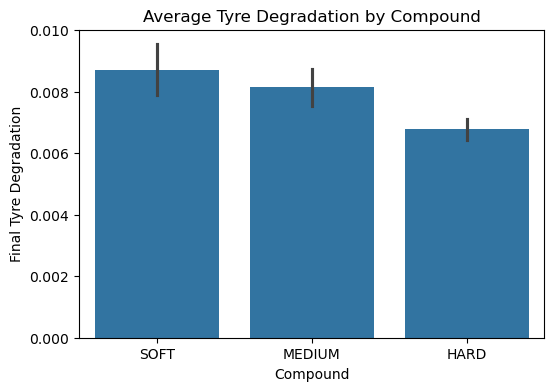

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = df[df["Compound"].isin(["SOFT", "MEDIUM", "HARD"])]

plt.figure(figsize=(6,4))
sns.barplot(
    data=plot_df,
    x="Compound",
    y="FinalTyreDegradation",
    order=["SOFT", "MEDIUM", "HARD"]
)
plt.title("Average Tyre Degradation by Compound")
plt.ylabel("Final Tyre Degradation")
plt.show()


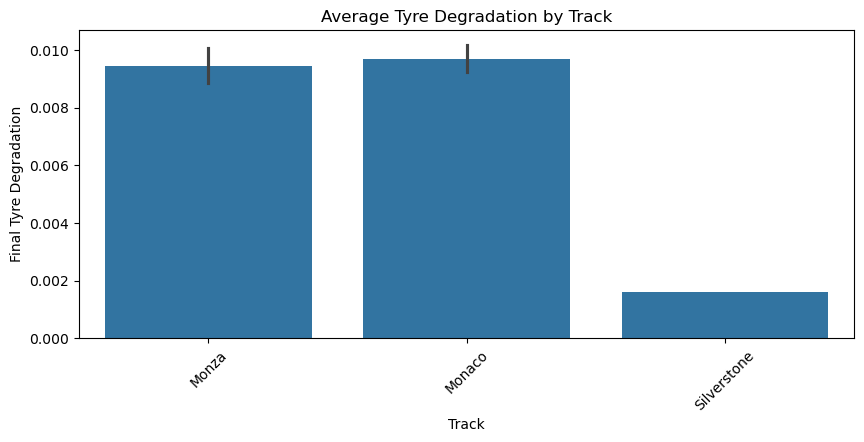

In [90]:
plt.figure(figsize=(10,4))
sns.barplot(
    data=plot_df,
    x="Track",
    y="FinalTyreDegradation"
)
plt.xticks(rotation=45)
plt.title("Average Tyre Degradation by Track")
plt.ylabel("Final Tyre Degradation")
plt.show()


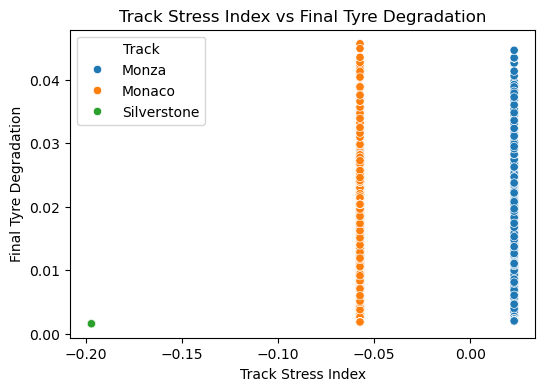

In [92]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=plot_df,
    x="TrackStressIndex",
    y="FinalTyreDegradation",
    hue="Track"
)
plt.title("Track Stress Index vs Final Tyre Degradation")
plt.xlabel("Track Stress Index")
plt.ylabel("Final Tyre Degradation")
plt.show()


In [94]:
import numpy as np

PACE_MULTIPLIER = {
    "PUSH": 1.15,     # more degradation
    "NORMAL": 1.0,    # baseline
    "SAVE": 0.85      # less degradation
}

def predict_stint_life(
    track,
    compound,
    pace="NORMAL",
    starting_age_laps=0,
    start_health=1.0,
    dead_threshold=0.2,
    max_laps=100
):
    """
    Predict tyre life in laps using realistic user inputs only.
    """

    # Filter dataset
    subset = df[
        (df["Track"] == track) &
        (df["Compound"].str.upper() == compound.upper())
    ]

    if subset.empty:
        return None

    # Base degradation per lap (from data)
    base_deg = subset["FinalTyreDegradation"].mean()

    # Apply pace multiplier
    pace = pace.upper()
    pace_factor = PACE_MULTIPLIER.get(pace, 1.0)
    deg_per_lap = base_deg * pace_factor

    # Reduce health due to used tyres
    health = start_health - starting_age_laps * deg_per_lap
    health = max(health, 0)

    laps = 0
    health_curve = []

    while health > dead_threshold and laps < max_laps:
        health_curve.append(health)
        health -= deg_per_lap
        laps += 1

    return {
        "predicted_life_laps": laps,
        "degradation_per_lap": deg_per_lap,
        "health_curve": health_curve
    }


In [96]:
print(predict_stint_life("Monaco", "SOFT", pace="PUSH"))
print(predict_stint_life("Monaco", "SOFT", pace="SAVE"))
print(predict_stint_life("Monza", "MEDIUM", pace="NORMAL"))


{'predicted_life_laps': 58, 'degradation_per_lap': 0.013819273921557086, 'health_curve': [1.0, 0.9861807260784429, 0.9723614521568857, 0.9585421782353286, 0.9447229043137715, 0.9309036303922144, 0.9170843564706572, 0.9032650825491001, 0.889445808627543, 0.8756265347059858, 0.8618072607844287, 0.8479879868628716, 0.8341687129413144, 0.8203494390197573, 0.8065301650982002, 0.7927108911766431, 0.7788916172550859, 0.7650723433335288, 0.7512530694119717, 0.7374337954904145, 0.7236145215688574, 0.7097952476473003, 0.6959759737257432, 0.682156699804186, 0.6683374258826289, 0.6545181519610718, 0.6406988780395146, 0.6268796041179575, 0.6130603301964004, 0.5992410562748433, 0.5854217823532861, 0.571602508431729, 0.5577832345101719, 0.5439639605886147, 0.5301446866670576, 0.5163254127455005, 0.5025061388239433, 0.4886868649023863, 0.4748675909808292, 0.46104831705927213, 0.44722904313771505, 0.433409769216158, 0.4195904952946009, 0.40577122137304383, 0.39195194745148676, 0.3781326735299297, 0.364

In [98]:
# Baseline lap time per track+compound from your dataset
baseline_map = (
    df[df["Compound"].str.upper().isin(["SOFT","MEDIUM","HARD"])]
    .assign(Compound=lambda x: x["Compound"].str.upper())
    .groupby(["Track","Compound"])["LapTimeSeconds"]
    .median()
    .to_dict()
)


In [100]:
def predict_stint_life_with_laptime(
    track,
    compound,
    current_lap_time=None,          # seconds
    pace="NORMAL",
    starting_age_laps=0,
    start_health=1.0,
    dead_threshold=0.2,
    max_laps=100,
    k=0.06                           # wear sensitivity per second
):
    subset = df[(df["Track"] == track) & (df["Compound"].str.upper() == compound.upper())]
    if subset.empty:
        return None

    base_deg = subset["FinalTyreDegradation"].mean()

    # pace multiplier (still works if current_lap_time isn't provided)
    pace_factor = PACE_MULTIPLIER.get(pace.upper(), 1.0)

    # lap-time multiplier
    lap_mult = 1.0
    if current_lap_time is not None:
        base_time = baseline_map.get((track, compound.upper()))
        if base_time is not None and base_time > 0:
            delta = current_lap_time - base_time  # + means slower, - means faster
            lap_mult = max(0.6, min(1.6, 1 - k * delta))  # clamp to avoid crazy values

    deg_per_lap = base_deg * pace_factor * lap_mult

    # account for used tyres
    health = start_health - starting_age_laps * deg_per_lap
    health = max(health, 0)

    laps = 0
    health_curve = []
    while health > dead_threshold and laps < max_laps:
        health_curve.append(health)
        health -= deg_per_lap
        laps += 1

    return {
        "predicted_life_laps": laps,
        "degradation_per_lap": deg_per_lap,
        "lap_time_multiplier": lap_mult,
        "health_curve": health_curve
    }


In [102]:
# Suppose Monaco Soft baseline is ~75s (example). Try faster/slower.
print(predict_stint_life_with_laptime("Monaco","SOFT", current_lap_time=74.5))
print(predict_stint_life_with_laptime("Monaco","SOFT", current_lap_time=75.5))


{'predicted_life_laps': 69, 'degradation_per_lap': 0.011642558027512866, 'lap_time_multiplier': 0.9688599999999997, 'health_curve': [1.0, 0.9883574419724871, 0.9767148839449742, 0.9650723259174613, 0.9534297678899484, 0.9417872098624355, 0.9301446518349226, 0.9185020938074097, 0.9068595357798968, 0.8952169777523838, 0.8835744197248709, 0.871931861697358, 0.8602893036698451, 0.8486467456423322, 0.8370041876148193, 0.8253616295873064, 0.8137190715597935, 0.8020765135322806, 0.7904339555047677, 0.7787913974772548, 0.7671488394497419, 0.755506281422229, 0.7438637233947161, 0.7322211653672032, 0.7205786073396903, 0.7089360493121774, 0.6972934912846644, 0.6856509332571515, 0.6740083752296386, 0.6623658172021257, 0.6507232591746128, 0.6390807011470999, 0.627438143119587, 0.6157955850920741, 0.6041530270645612, 0.5925104690370483, 0.5808679110095354, 0.5692253529820225, 0.5575827949545096, 0.5459402369269967, 0.5342976788994838, 0.5226551208719709, 0.511012562844458, 0.4993700048169451, 0.4877

In [104]:
def strategy_suggestions(track, compound, current_lap_time, starting_age_laps=0):
    """
    Runs multiple what-if scenarios and returns:
    - predicted life at current pace
    - life if you go a bit slower/faster
    - simple pit window
    - human-readable advice
    """
    # Baseline at current lap time
    base = predict_stint_life_with_laptime(
        track, compound,
        current_lap_time=current_lap_time,
        pace="NORMAL",
        starting_age_laps=starting_age_laps
    )
    if base is None:
        return None

    # What-if: go slower (save tyres) and faster (push)
    slower_02 = predict_stint_life_with_laptime(track, compound, current_lap_time=current_lap_time + 0.2,
                                                pace="NORMAL", starting_age_laps=starting_age_laps)
    slower_05 = predict_stint_life_with_laptime(track, compound, current_lap_time=current_lap_time + 0.5,
                                                pace="NORMAL", starting_age_laps=starting_age_laps)
    faster_02 = predict_stint_life_with_laptime(track, compound, current_lap_time=current_lap_time - 0.2,
                                                pace="NORMAL", starting_age_laps=starting_age_laps)

    # Extract lives
    L0 = base["predicted_life_laps"]
    Ls2 = slower_02["predicted_life_laps"] if slower_02 else None
    Ls5 = slower_05["predicted_life_laps"] if slower_05 else None
    Lf2 = faster_02["predicted_life_laps"] if faster_02 else None

    # Simple pit window: 70% to 90% of predicted life
    pit_early = int(round(0.70 * L0))
    pit_late  = int(round(0.90 * L0))

    # Build advice text
    advice = []
    advice.append(f"Predicted tyre life: ~{L0} laps at {current_lap_time:.1f}s pace.")

    if Ls2 is not None:
        advice.append(f"If you go ~0.2s slower per lap, you can gain ~{Ls2 - L0} laps (life becomes ~{Ls2} laps).")
    if Ls5 is not None:
        advice.append(f"If you go ~0.5s slower per lap, you can gain ~{Ls5 - L0} laps (life becomes ~{Ls5} laps).")
    if Lf2 is not None:
        advice.append(f"If you push ~0.2s faster per lap, you may lose ~{L0 - Lf2} laps (life becomes ~{Lf2} laps).")

    advice.append(f"Suggested pit window (simple): lap {pit_early} to {pit_late} (depends on race/traffic).")

    return {
        "baseline": base,
        "what_if": {"slower_0.2": slower_02, "slower_0.5": slower_05, "faster_0.2": faster_02},
        "pit_window": (pit_early, pit_late),
        "advice": advice
    }


In [106]:
result = strategy_suggestions("Monaco", "SOFT", current_lap_time=75.0, starting_age_laps=0)
for line in result["advice"]:
    print("-", line)


- Predicted tyre life: ~71 laps at 75.0s pace.
- If you go ~0.2s slower per lap, you can gain ~1 laps (life becomes ~72 laps).
- If you go ~0.5s slower per lap, you can gain ~3 laps (life becomes ~74 laps).
- If you push ~0.2s faster per lap, you may lose ~0 laps (life becomes ~71 laps).
- Suggested pit window (simple): lap 50 to 64 (depends on race/traffic).


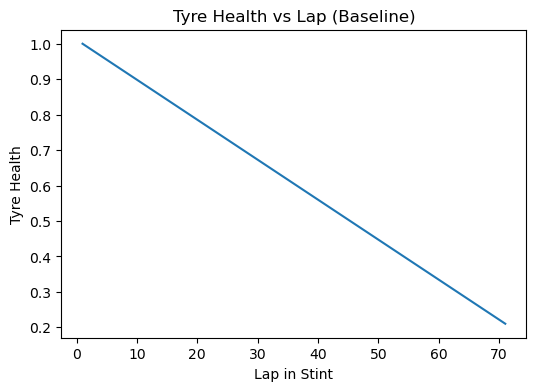

In [108]:
import matplotlib.pyplot as plt

hc = result["baseline"]["health_curve"]
plt.figure(figsize=(6,4))
plt.plot(range(1, len(hc)+1), hc)
plt.title("Tyre Health vs Lap (Baseline)")
plt.xlabel("Lap in Stint")
plt.ylabel("Tyre Health")
plt.show()


In [110]:
def apply_fuel_effect(result, fuel_start_factor=1.05):
    """
    Adjusts tyre life based on fuel burn-off.
    Fuel effect is strongest early and fades over the stint.
    """

    base_life = result["predicted_life_laps"]
    if base_life == 0:
        return result

    adjusted_health_curve = []
    hc = result["health_curve"]

    for lap, h in enumerate(hc):
        fuel_factor = fuel_start_factor - (fuel_start_factor - 1.0) * (lap / base_life)
        fuel_factor = max(1.0, fuel_factor)
        adjusted_health_curve.append(h / fuel_factor)

    # recompute life using adjusted curve
    new_life = sum(1 for h in adjusted_health_curve if h > 0.2)

    result_fuel = result.copy()
    result_fuel["health_curve"] = adjusted_health_curve
    result_fuel["predicted_life_laps"] = new_life
    result_fuel["fuel_model"] = "implicit_linear_burn"

    return result_fuel


In [112]:
base_result = predict_stint_life_with_laptime(
    "Monaco", "SOFT", current_lap_time=75.0
)

fuel_adjusted = apply_fuel_effect(base_result)

print("Base life:", base_result["predicted_life_laps"])
print("Fuel-adjusted life:", fuel_adjusted["predicted_life_laps"])


Base life: 71
Fuel-adjusted life: 71


In [114]:
print("Last 5 base health:", base_result["health_curve"][-5:])
print("Last 5 fuel health:", fuel_adjusted["health_curve"][-5:])


Last 5 base health: [0.25538435484909405, 0.24410229961953486, 0.23282024438997567, 0.22153818916041648, 0.2102561339308573]
Last 5 fuel health: [0.2544882693934832, 0.24341661900262607, 0.23232940761332777, 0.2212266023964778, 0.21010817043055408]


In [116]:
def simulate_with_fuel(base_result, deg_per_lap, dead_threshold=0.2, max_laps=200, fuel_start_factor=1.05):
    """
    Independent simulation using per-lap fuel burn.
    fuel_start_factor > 1 makes early laps wear more.
    """
    health = 1.0
    health_curve = []
    laps = 0

    while health > dead_threshold and laps < max_laps:
        health_curve.append(health)

        # fuel factor fades from fuel_start_factor -> 1.0
        fuel_factor = fuel_start_factor - (fuel_start_factor - 1.0) * (laps / max(1, base_result["predicted_life_laps"]))
        fuel_factor = max(1.0, fuel_factor)

        health -= deg_per_lap * fuel_factor
        laps += 1

    return {"predicted_life_laps": laps, "health_curve": health_curve}


In [118]:
base_result = predict_stint_life_with_laptime("Monaco", "SOFT", current_lap_time=75.0)
deg = base_result["degradation_per_lap"]

fuel_sim = simulate_with_fuel(base_result, deg, fuel_start_factor=1.08)

print("Base life:", base_result["predicted_life_laps"])
print("Fuel sim life:", fuel_sim["predicted_life_laps"])


Base life: 71
Fuel sim life: 69


In [120]:
def website_predict(track, compound, lap_time, tyre_age_laps=0, fuel_start_factor=1.08):
    base = predict_stint_life_with_laptime(
        track,
        compound,
        current_lap_time=lap_time,
        starting_age_laps=tyre_age_laps
    )
    if base is None:
        return None

    fuel = simulate_with_fuel(
        base,
        base["degradation_per_lap"],
        fuel_start_factor=fuel_start_factor
    )

    L = fuel["predicted_life_laps"]
    pit_window = (int(0.70 * L), int(0.90 * L))

    advice = [
        f"Predicted tyre life: ~{L} laps at {lap_time:.1f}s pace.",
        f"Suggested pit window: lap {pit_window[0]} to {pit_window[1]}.",
        "Slowing by ~0.2s/lap can extend tyre life by a few laps."
    ]

    return {
        "track": track,
        "compound": compound.upper(),
        "lap_time": lap_time,
        "tyre_age_laps": tyre_age_laps,
        "life_laps": L,
        "pit_window": pit_window,
        "advice": advice,
        "health_curve": fuel["health_curve"]
    }


In [122]:
out = website_predict("Monaco", "SOFT", 75.0)
print(out["life_laps"], out["pit_window"])
for a in out["advice"]:
    print("-", a)


69 (48, 62)
- Predicted tyre life: ~69 laps at 75.0s pace.
- Suggested pit window: lap 48 to 62.
- Slowing by ~0.2s/lap can extend tyre life by a few laps.


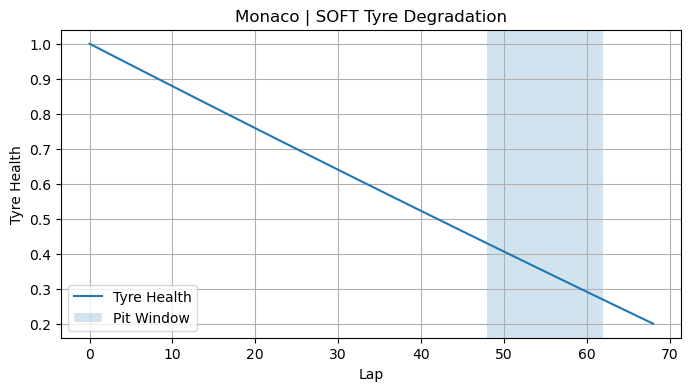

In [124]:
import matplotlib.pyplot as plt

# 1) generate prediction output
out = website_predict("Monaco", "SOFT", 75.0)

# 2) plot health curve + pit window
health = out["health_curve"]

plt.figure(figsize=(8,4))
plt.plot(range(len(health)), health, label="Tyre Health")
plt.axvspan(out["pit_window"][0], out["pit_window"][1], alpha=0.2, label="Pit Window")

plt.xlabel("Lap")
plt.ylabel("Tyre Health")
plt.title(f"{out['track']} | {out['compound']} Tyre Degradation")
plt.legend()
plt.grid(True)
plt.show()
